# TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## Exercise 1: 

The dataset gets loaded into a dataframe, and the relevant column indices are extracted. The dataframe is then converted to a GeoDataFrame to better store the coordinates of the data points. The world map data is loaded into another GeoDataFrame, which is then cropped to only include the Americas, and plotted. Then every tribe is plotted on the map by going through every unique population name and creating a scatter plot on the map using the coordinates of the datapoint.

(494, 5717)


/tmp/ipykernel_117845/1350480817.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


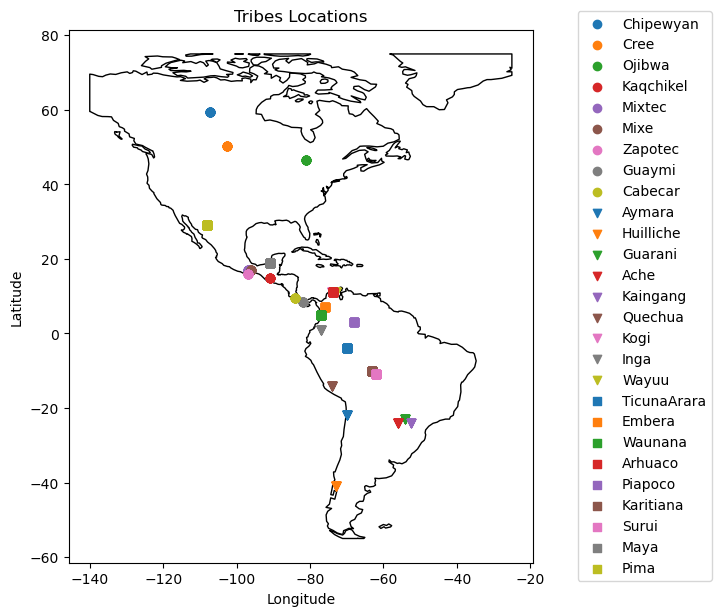

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')
print(df.shape)

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## Exercise 2:

**(a)** 

In [17]:
import numpy as np
# Get the genetic markers
X = df[df.columns[8:]].values
print(X.shape)
y = df['long']
print(y.shape)

# Get the regression coefficients
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)
print("parameters:")
print(beta_hat)

(494, 5709)
(494,)


LinAlgError: Singular matrix

I get the error `Singular matrix`, which means that $X^T X$ is not invertible. Since $rank(X) < p$, and $X^T X$ has size $p \times p$, some of the rows of $X^T X$ will be linearly dependent, which makes it singular.

**(b)** 

In [3]:
# Estimate the coefficients using least squares
beta_hat, residuals, rank, s = np.linalg.lstsq(X, y)
print("parameters:")
print(beta_hat)

parameters:
[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


Now I get no errors.

This is becaue `numpy.linalg.solve` will always try to solve the provided equation, but `numpy.linalg.lstsq` will solve the system using least squares when the system is overdetermined, but when the system is underdetermined it instead finds the minimum norm solution.

 **(c)**

In [4]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


The coefficients are not the same as before. A reason to perform the re-centering systematically is so that the intercept will be the predicted value when all predictors have their average value, which lets us interpret the intercept as the mean value regardless of the other coefficients.

## Exercise 3:

**(a)** 

Principal component analysis means finding the n components that explain the most variance of the dataset, projecting the data to a lower dimensionality space by taking using the eigenvectors with the highest absolute eigenvalues.

**(b)** 

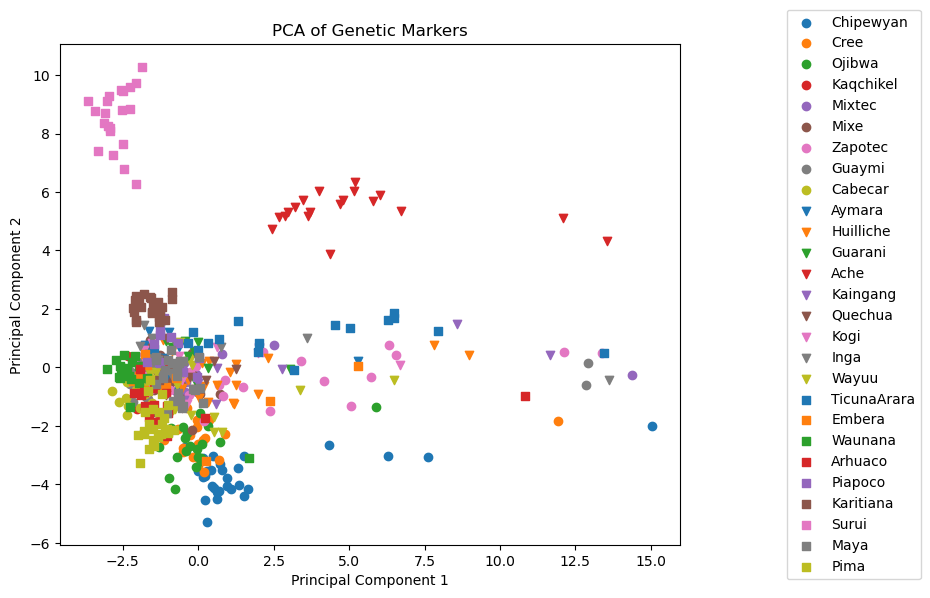

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
X_reduced = pca.transform(X)

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(8.0, 6.5))

for i, tribe in enumerate(gdf['Pop'].unique()):
    points_tribe = X_reduced[gdf['Pop'] == tribe]
    ax.scatter(points_tribe[:, 0], points_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

ax.set_title('PCA of Genetic Markers')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.show()

**(c)** 

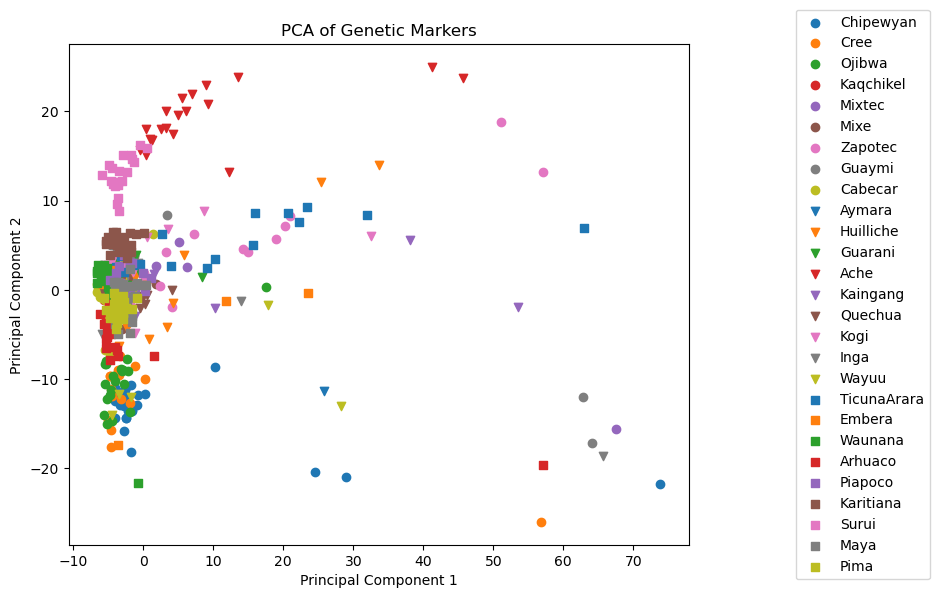

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
pca = PCA(n_components=2)
pca.fit(X_std)
X_reduced_std = pca.transform(X_std)

fig, ax = plt.subplots(figsize=(8.0, 6.5))

for i, tribe in enumerate(gdf['Pop'].unique()):
    points_tribe = X_reduced_std[gdf['Pop'] == tribe]
    ax.scatter(points_tribe[:, 0], points_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

ax.set_title('PCA of Genetic Markers')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.show()

The points are more spread out on the on the principal component 1 axis, going up to 70 instead of 15. The variance within each tribe seems to be lower. 

**(d)** 

The standardizing makes the points more spread out, and it gives a better separation of the data along principal component 2, but a worse separation along principal component 1. Since all the markers have values 1 or 0, it makes sense that the scaling wouldn't improve the performance of the PCA, which is what seems to be what is happening here. This means that the scaling is not necessary.

**(e)** 

Percentage of variance captured by the first two principal components: 3.3929133203688058


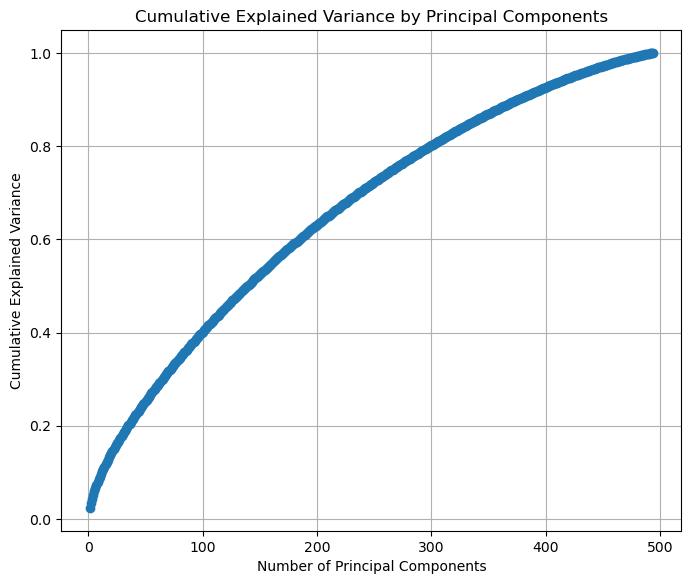

In [7]:
pca = PCA()
pca.fit(X_std)

print("Percentage of variance captured by the first two principal components:", pca.explained_variance_ratio_[:2].sum() * 100)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8.0, 6.5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid()
plt.show()

The first two components capture 3.393% of the variance. The graph intersects 50% of the variance at around 150 components. This can be considered as a minimum number of components to keep to explain the majority of the variance of the data. 

## Exercise 4:

**(a)** 

/tmp/ipykernel_117845/1630627290.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


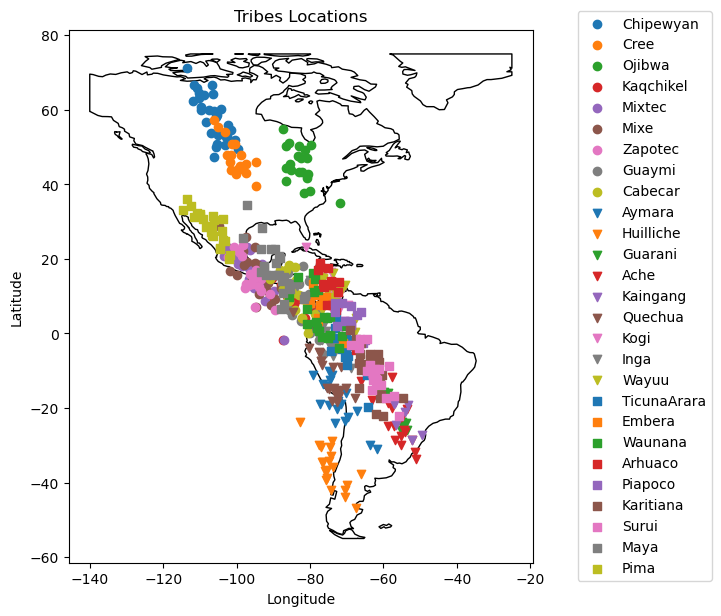

In [8]:
from sklearn.pipeline import make_pipeline

y = df[['long', 'lat']].values

pca = PCA(n_components=250)
regression = LinearRegression()

pipeline = make_pipeline(pca, regression)
pipeline.fit(X, y)
predictions = pipeline.predict(X)

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = predictions[gdf['Pop'] == tribe]
    ax.scatter(members_tribe[:, 0], members_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The map shows the performance on the training set, so it doesn't say anything about the ability make predictions on points outside the dataset. Using the map to judge the ability to predict points outside the dataset would be way too optimistic. 

**(b)**

In [9]:
from sklearn.metrics.pairwise import haversine_distances

distances = haversine_distances(np.radians(y), np.radians(predictions)) * 6371
mean_error = distances.diagonal().mean()
mean_error_km = mean_error
print(f"Mean error: {mean_error_km:.3f} km")

Mean error: 374.110 km


The mean error is 374.110 km.

## Exercise 5: 

Cross validation means saving a part of the dataset to use for testing, in order to estimate the error on data that was not used in training. This gives a better measure of how our model performs, letting us better choose the hyperparameters to get the best bias-variance tradeoff. For data that is not IID, for example due to having a structure with different groups or coming from a time-sensitive process, group-wise cross validation or time-series aware cross validation can be performed. 

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The data is sorted by country and tribe, meaning that simple k-fold without shuffling will lead to different distributions of the countries and tribes in the training and test set. Using shuffled k-fold reduces the effect of this by making sure the data is not sorted. Another problem could be that the model might overfit to the markers specific to these tribes or countries, making it perform worse at predicting the location of individuals from different tribes or countries. To avoid this, grouped k-fold can be used, which makes sure that each group is in one testing set and no group is in both the training and testing set.

**(c)**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
kf = KFold(n_splits=10, shuffle=True)
gkf = GroupKFold(n_splits=10, shuffle=True)
groups = groups = gdf['Pop'].values

pca = PCA(n_components=4)
regression = LinearRegression()
pipeline = make_pipeline(pca, regression)

errors = []


for i, (train, test) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    error = haversine_distances(np.radians(y_test), np.radians(predictions)).diagonal().mean()*6371
    errors.append(error)
    print(f"Error for split {i}: {error:.5f} km")

print(f"Mean error for all splits: {sum(errors)/len(errors):.5f} km")


Error for split 0: 1601.67003 km
Error for split 1: 810.08740 km
Error for split 2: 1273.60127 km
Error for split 3: 1392.85218 km
Error for split 4: 1217.85605 km
Error for split 5: 955.34434 km
Error for split 6: 2374.16916 km
Error for split 7: 1908.48005 km
Error for split 8: 1309.79581 km
Error for split 9: 1548.15994 km
Mean error for all splits: 1439.20162 km


**(d)**

Mean testing and training error for 2 components: 1514.2642383791585, 1253.6183190788183
Mean testing and training error for 12 components: 1415.7422026782306, 810.1746763563211
Mean testing and training error for 22 components: 1329.9189167625552, 645.0160181697815
Mean testing and training error for 32 components: 1319.1137486078283, 609.6228851545321
Mean testing and training error for 42 components: 1316.1580660486063, 578.6554493710295
Mean testing and training error for 52 components: 1313.3542547868112, 567.1686824266671
Mean testing and training error for 62 components: 1312.6597044921712, 550.5511731963954
Mean testing and training error for 72 components: 1310.0145037687116, 534.2489415177254
Mean testing and training error for 82 components: 1297.4284364365699, 522.7399816144485
Mean testing and training error for 92 components: 1306.6603442518835, 509.2567821025876
Mean testing and training error for 102 components: 1305.887292507526, 496.09709701729525
Mean testing and tra

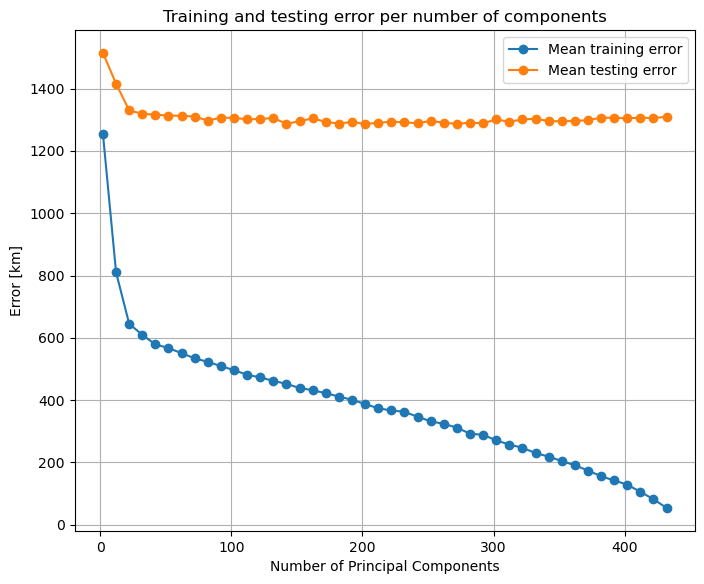

In [11]:
n_components_values = range(2, 441, 10)
mean_training_errors = []
mean_testing_errors = []


gkf = GroupKFold(n_splits=10)


for n in n_components_values:
    pca = PCA(n_components=n)
    regression = LinearRegression()
    pipeline = make_pipeline(pca, regression)
    
    training_errors = []
    testing_errors = []

    for train, test in gkf.split(X, y, groups=groups):
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_test)
        training_predictions = pipeline.predict(X_train)
        training_error = haversine_distances(np.radians(y_train), np.radians(training_predictions)).diagonal().mean()*6371
        testing_error = haversine_distances(np.radians(y_test), np.radians(test_predictions)).diagonal().mean()*6371
        training_errors.append(training_error)
        testing_errors.append(testing_error)



    mean_testing_error = np.mean(testing_errors)
    mean_training_error = np.mean(training_errors)
    print(f"Mean testing and training error for {n} components: {mean_testing_error}, {mean_training_error}")

    mean_testing_errors.append(mean_testing_error)
    mean_training_errors.append(mean_training_error)


plt.figure(figsize=(8.0, 6.5))
plt.plot(n_components_values, mean_training_errors, marker='o', label="Mean training error")
plt.plot(n_components_values, mean_testing_errors, marker='o', label="Mean testing error")
plt.xlabel('Number of Principal Components')
plt.ylabel('Error [km]')
plt.title('Training and testing error per number of components')
plt.grid()
plt.legend()
plt.show()

**(e)** 

I would keep 192 components, as it explains more than 50% of the variance and gives a testing error that is close to the minimum found. It gives a prediction error of 1292.98 km and a training error of 400.87 km. 

/tmp/ipykernel_117845/2488598137.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


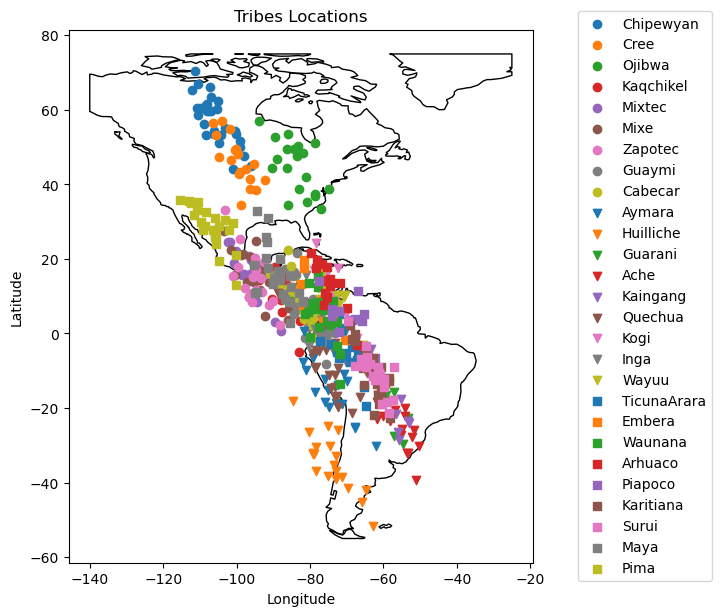

In [12]:
from sklearn.pipeline import make_pipeline

y = df[['long', 'lat']].values

pca = PCA(n_components=192)
regression = LinearRegression()
gkf = GroupKFold(n_splits=10, shuffle=True)

pipeline = make_pipeline(pca, regression)
pipeline.fit(X, y)
predictions = pipeline.predict(X)


# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = predictions[gdf['Pop'] == tribe]
    ax.scatter(members_tribe[:, 0], members_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The model still predicts the correct general area for the tribes, but there is more variance between the points within each tribe compared to the plot from 4a. Since we are plotting the points in the training set and the testing error was much higher than the training error, we can expect the error on real data to be much higher than what the plot suggests, closer to the testing error.

## Exercise 6: 

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

Mean error for Canada: 469.606 km
Mean error for Guatemala: 630.148 km
Mean error for Mexico: 404.851 km
Mean error for Panama: 403.183 km
Mean error for CostaRica: 290.355 km
Mean error for Chile: 646.441 km
Mean error for Brazil: 459.131 km
Mean error for Paraguay: 563.431 km
Mean error for Peru: 417.840 km
Mean error for Colombia: 382.880 km


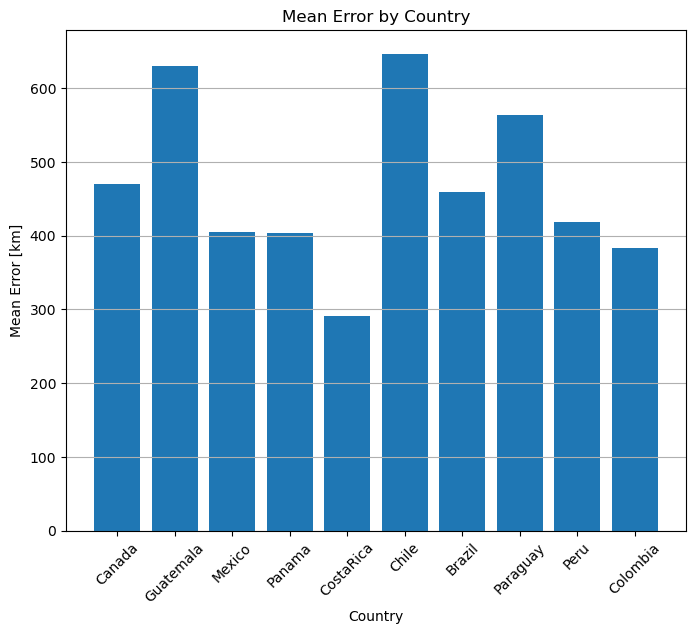

In [13]:
countries = gdf['Country'].unique()
error_by_country = {}

for country in countries:
    predictions_country = predictions[gdf['Country'] == country]
    y_country = y[gdf['Country'] == country]
    error_country = haversine_distances(np.radians(y_country), np.radians(predictions_country)).diagonal().mean()*6371
    error_by_country[country] = error_country
    print(f"Mean error for {country}: {error_country:.3f} km")

plt.figure(figsize=(8.0, 6.5))
plt.bar(error_by_country.keys(), error_by_country.values())
plt.xlabel('Country')
plt.ylabel('Mean Error [km]')
plt.title('Mean Error by Country')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [16]:
print(regression.coef_)

[[ 6.20025458e-02  3.85263400e+00  1.82716531e+00 -1.26465775e+00
   8.74689768e-01 -1.44364759e+00  6.07633247e-01 -1.11622373e+00
  -1.30030097e+00 -6.09215171e-01 -9.38509074e-01 -5.31055153e-01
   5.03346046e-01 -2.77221914e+00 -1.92672794e+00  9.35228928e-01
   1.05128710e+00 -5.13113212e-01 -1.02528842e+00  5.70066117e-01
   3.90498817e-01 -9.33643891e-01 -7.02626855e-01 -4.39207369e-01
   5.26467748e-01 -5.08570467e-01 -3.74589507e-01 -5.86059260e-02
   1.07598051e-02  2.78323083e-01 -4.81691568e-01  5.70698819e-01
   3.91263169e-01 -3.10599018e-02 -1.19637377e+00  2.69013163e-01
  -3.69161188e-02  2.01514468e-01 -6.52906310e-01  1.42502443e-01
   2.65498799e-01 -4.05291773e-01  3.62710625e-01 -5.61486536e-01
  -2.48789380e-01  1.81443899e-01 -2.47333312e-01  6.54775925e-02
  -6.08209036e-01 -2.45739214e-01 -7.40411046e-01 -3.85980509e-02
   2.49580216e-01 -8.92078784e-02  1.36916741e-02  1.55030246e-02
   5.38603027e-01 -5.63449807e-01  4.45006474e-01  1.88386958e-01
   6.98000

In this study we have shown that PCA can be used on this dataset with more columns than rows to reduce the number of features in order to make predictions through linear regression. We found that by choosing the number of principal components used we can adapt the model to have a good variance-bias tradeoff. 

The final model takes the first 192 principal components of the geneteic markers as predictors, with the coefficients for each component as seen above. 


The performance of the model is fairly even across the different countries, with Costa Rica standing out with the lowest training error and Chile and Guatemala having the highest training errors. A reason for this could be that the model predicts most individuals to be on the general diagonal of the landmass of the Americas, causing a higher error where the diagonal crosses the ocean where there are no points in the dataset.